In [1]:
# 1. IMPORT LIBRARIES
# ---------------------------
# These libraries handle files, randomness, numerical work,
# plotting, TensorFlow models, MATLAB split files, and metrics.

import os
import time
import tarfile
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from scipy.io import loadmat
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# 2. REPRODUCIBILITY
# ---------------------------
# A fixed seed reduces unnecessary randomness between runs.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)


Random seed: 42


In [3]:
# 3. EXPERIMENT SETTINGS
# ---------------------------
# Both models will use the same image size, batch size and
# number of flower classes.

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32
NUM_CLASSES = 17

class_names = [
    "Daffodil",
    "Snowdrop",
    "Lily Valley",
    "Bluebell",
    "Crocus",
    "Iris",
    "Tigerlily",
    "Tulip",
    "Fritillary",
    "Sunflower",
    "Daisy",
    "Colts Foot",
    "Dandelion",
    "Cowslip",
    "Buttercup",
    "Windflower",
    "Pansy"
]

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)



Image size: (224, 224)
Batch size: 32
Number of classes: 17


In [5]:
# 4. UPLOAD DATA FILES
# ---------------------------
# Upload BOTH files when prompted:
#   17flowers.tgz
#   datasplits.mat
#
# Skip this cell if the files already exist in /content/.

from google.colab import files

required_files = ["/content/17flowers.tgz", "/content/datasplits.mat"]

if not all(os.path.exists(path) for path in required_files):
    print("Please upload 17flowers.tgz and datasplits.mat")
    uploaded = files.upload()
else:
    print("Dataset files already found in /content/.")

Please upload 17flowers.tgz and datasplits.mat


Saving datasplits.mat to datasplits.mat
Saving 17flowers.tgz to 17flowers (1).tgz


In [7]:
# ---------------------------
# 5. EXTRACT THE FLOWER IMAGES
# ---------------------------
# The .tgz archive is unpacked into /content/flowers17.

archive_path = "/content/17flowers.tgz"
extract_path = "/content/flowers17"
image_folder = os.path.join(extract_path, "jpg")

if not os.path.exists(image_folder):
    os.makedirs(extract_path, exist_ok=True)

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=extract_path)

    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

image_files = sorted([
    filename
    for filename in os.listdir(image_folder)
    if filename.lower().endswith(".jpg")
])

print("Number of JPG images:", len(image_files))

assert len(image_files) == 1360, "Expected 1,360 flower images."

print("Dataset verification successful.")

/tmp/ipykernel_1078/2488208491.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Dataset extracted.
Number of JPG images: 1360
Dataset verification successful.


In [8]:
# 6. LOAD THE OFFICIAL OXFORD SPLIT
# ---------------------------
# We use Oxford's predefined Split 1:
#   trn1 = 680 images
#   val1 = 340 images
#   tst1 = 340 images

split_path = "/content/datasplits.mat"
splits = loadmat(split_path)

train_indices = splits["trn1"].flatten().astype(int)
val_indices = splits["val1"].flatten().astype(int)
test_indices = splits["tst1"].flatten().astype(int)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Test images:", len(test_indices))

Training images: 680
Validation images: 340
Test images: 340


In [9]:
# 7. CHECK FOR DATA LEAKAGE
# ---------------------------
# No image should appear in more than one split.

train_set = set(train_indices.tolist())
val_set = set(val_indices.tolist())
test_set = set(test_indices.tolist())

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

all_indices = train_set | val_set | test_set

assert len(all_indices) == 1360

print("No overlap detected between train, validation and test sets.")


No overlap detected between train, validation and test sets.


In [10]:
# 8. BUILD IMAGE PATHS AND LABELS
# ---------------------------
# Oxford images are arranged in blocks of 80 images per class.
#
# Images 1-80    -> class 0
# Images 81-160  -> class 1
# ...
# Images 1281-1360 -> class 16

def build_split_data(indices):
    file_paths = []
    labels = []

    for image_number in indices:
        image_number = int(image_number)

        filename = f"image_{image_number:04d}.jpg"
        file_path = os.path.join(image_folder, filename)

        label = (image_number - 1) // 80

        file_paths.append(file_path)
        labels.append(label)

    return file_paths, np.array(labels, dtype=np.int32)


train_paths, train_labels = build_split_data(train_indices)
val_paths, val_labels = build_split_data(val_indices)
test_paths, test_labels = build_split_data(test_indices)

assert all(os.path.exists(path) for path in train_paths + val_paths + test_paths)

print("All image paths verified.")

All image paths verified.


In [11]:
# 9. CHECK CLASS BALANCE
# ---------------------------
# Each Oxford split should contain the same number of images
# from every flower class.

def show_class_counts(labels, split_name):
    counts = np.bincount(labels, minlength=NUM_CLASSES)

    print(f"\n{split_name}")
    for i, count in enumerate(counts):
        print(f"{class_names[i]}: {count}")


show_class_counts(train_labels, "TRAINING SET")
show_class_counts(val_labels, "VALIDATION SET")
show_class_counts(test_labels, "TEST SET")



TRAINING SET
Daffodil: 40
Snowdrop: 40
Lily Valley: 40
Bluebell: 40
Crocus: 40
Iris: 40
Tigerlily: 40
Tulip: 40
Fritillary: 40
Sunflower: 40
Daisy: 40
Colts Foot: 40
Dandelion: 40
Cowslip: 40
Buttercup: 40
Windflower: 40
Pansy: 40

VALIDATION SET
Daffodil: 20
Snowdrop: 20
Lily Valley: 20
Bluebell: 20
Crocus: 20
Iris: 20
Tigerlily: 20
Tulip: 20
Fritillary: 20
Sunflower: 20
Daisy: 20
Colts Foot: 20
Dandelion: 20
Cowslip: 20
Buttercup: 20
Windflower: 20
Pansy: 20

TEST SET
Daffodil: 20
Snowdrop: 20
Lily Valley: 20
Bluebell: 20
Crocus: 20
Iris: 20
Tigerlily: 20
Tulip: 20
Fritillary: 20
Sunflower: 20
Daisy: 20
Colts Foot: 20
Dandelion: 20
Cowslip: 20
Buttercup: 20
Windflower: 20
Pansy: 20


In [12]:
# 10. BUILD THE TENSORFLOW INPUT PIPELINE
# ---------------------------
# The shared data pipeline:
#   - reads the JPEG
#   - converts it to RGB
#   - resizes it to 224 x 224
#   - converts pixels to float32
#
# Normalisation is intentionally handled inside each model.

AUTOTUNE = tf.data.AUTOTUNE


def load_image(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


train_raw_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_raw_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_raw_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


train_ds = (
    train_raw_ds
    .shuffle(
        buffer_size=len(train_paths),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


val_ds = (
    val_raw_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


test_ds = (
    test_raw_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("\nProcessed dataset specification:")
print(train_ds.element_spec)


Processed dataset specification:
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [13]:
# 11. VERIFY ONE BATCH
# ---------------------------
# We check the shape, data type and pixel range before
# building any model.

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())



Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Minimum pixel value: 0.0
Maximum pixel value: 255.0


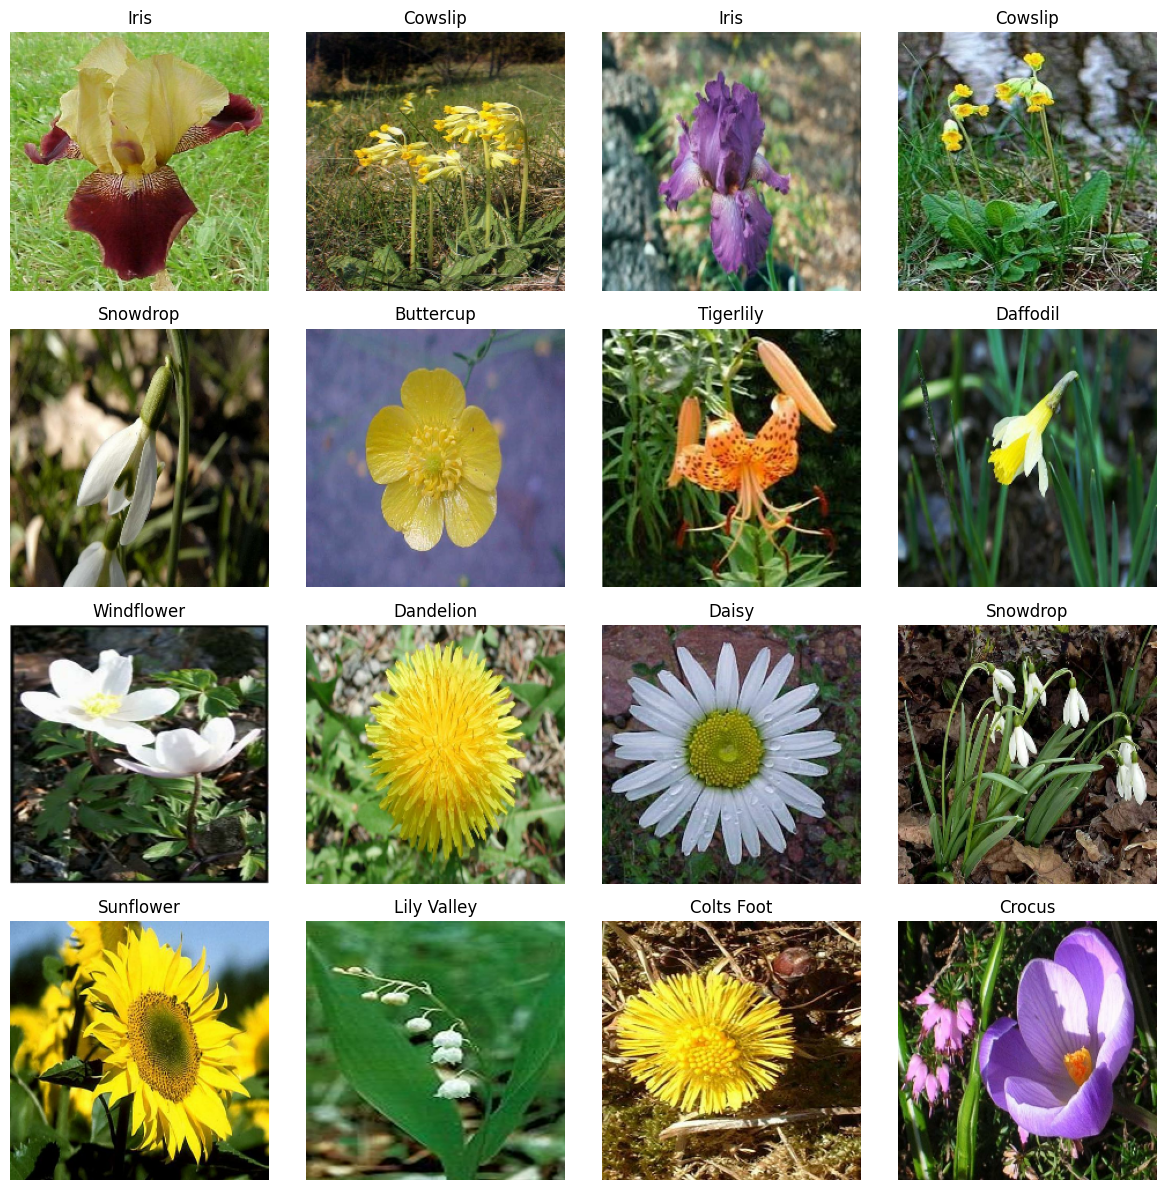

In [14]:
# 12. VISUALISE A TRAINING BATCH
# ---------------------------
# This confirms that images and labels still match after the
# TensorFlow input pipeline.

plt.figure(figsize=(12, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# ---------------------------
# 13. COMMON DATA AUGMENTATION
# ---------------------------
# These transformations create slightly different versions
# of training images and can reduce overfitting.
#
# They are active during training only.

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


In [17]:
# MODEL 1: CNN FROM SCRATCH
# ============================================================

# ---------------------------
# 14. BUILD THE SCRATCH CNN
# ---------------------------
# This model starts with random weights and must learn all
# visual features directly from the 680 training images.

scratch_model = keras.Sequential(
    [
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Convert pixels from roughly 0-255 to 0-1.
        layers.Rescaling(1.0 / 255),

        data_augmentation,

        # Early convolution layers learn simple patterns such
        # as edges, colours and textures.
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # Compress each feature map into one summary value.
        layers.GlobalAveragePooling2D(),

        # Dropout reduces reliance on individual neurons.
        layers.Dropout(0.30),

        # Final probabilities for the 17 flower classes.
        layers.Dense(NUM_CLASSES, activation="softmax")
    ],
    name="scratch_cnn"
)

scratch_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

scratch_model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,785 (1.50 MB)

 Trainable params: 392,785 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# 15. TRAIN THE SCRATCH CNN
# ---------------------------
# EarlyStopping prevents unnecessary training after validation
# loss stops improving.

scratch_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

start_time = time.time()

scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=scratch_callbacks,
    verbose=1
)

scratch_training_time = time.time() - start_time

print(f"Scratch CNN training time: {scratch_training_time:.2f} seconds")


Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.0515 - loss: 2.8336 - val_accuracy: 0.1059 - val_loss: 2.7867
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.1015 - loss: 2.7061 - val_accuracy: 0.1118 - val_loss: 2.5446
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.1162 - loss: 2.5322 - val_accuracy: 0.1324 - val_loss: 2.5115
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.1868 - loss: 2.4224 - val_accuracy: 0.1941 - val_loss: 2.3622
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.2118 - loss: 2.2443 - val_accuracy: 0.3412 - val_loss: 2.0365
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.2544 - loss: 2.1392 - val_accuracy: 0.3441 - val_loss: 1.9615
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.3132 - loss: 2.0139 - val_accuracy: 0.3912 - val_loss: 1.8938
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.3441 - loss: 1.9541 - val_accuracy: 0.4235

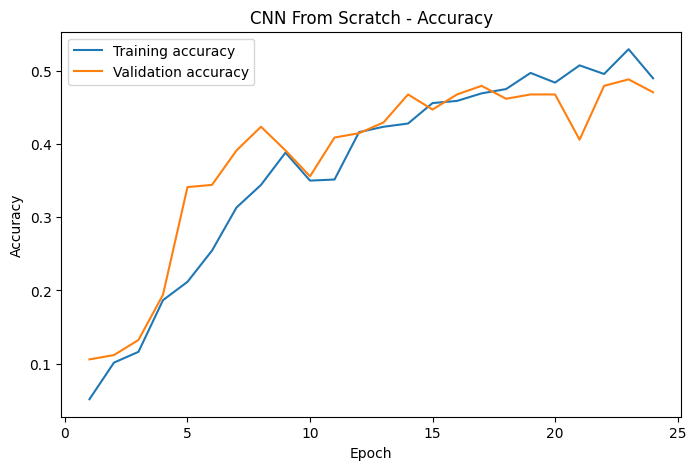

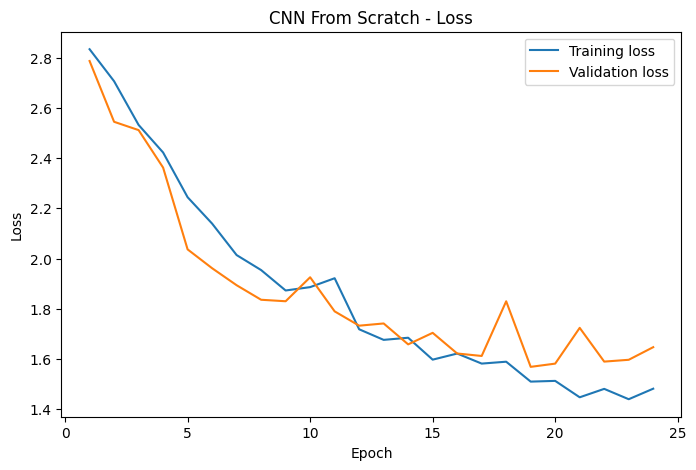

In [35]:
# 16. PLOT SCRATCH CNN HISTORY
# ---------------------------

def plot_history(history, title):
    epochs = range(1, len(history.history["accuracy"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history.history["accuracy"], label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history.history["loss"], label="Training loss")
    plt.plot(epochs, history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()


plot_history(scratch_history, "CNN From Scratch")


In [19]:
# MODEL 2: MOBILENETV2 TRANSFER LEARNING
# ============================================================

# ---------------------------
# 17. BUILD MOBILENETV2
# ---------------------------
# MobileNetV2 has already learned useful visual patterns from
# ImageNet. The convolutional base is frozen initially.

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = data_augmentation(inputs)

# MobileNetV2 expects its own input scaling, approximately
# mapping pixel values from 0-255 to -1 to 1.
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# training=False keeps BatchNorm layers in inference mode.
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.20)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenet_model = keras.Model(
    inputs,
    outputs,
    name="mobilenetv2_transfer"
)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │        21,777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,279,761 (8.70 MB)

 Trainable params: 21,777 (85.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# 18. TRAIN MOBILENETV2
# ---------------------------

mobilenet_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

start_time = time.time()

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=mobilenet_callbacks,
    verbose=1
)

mobilenet_training_time = time.time() - start_time

print(
    f"MobileNetV2 training time: "
    f"{mobilenet_training_time:.2f} seconds"
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - accuracy: 0.2221 - loss: 2.5424 - val_accuracy: 0.6029 - val_loss: 1.5945
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6338 - loss: 1.3194 - val_accuracy: 0.8000 - val_loss: 0.9490
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.7941 - loss: 0.8470 - val_accuracy: 0.8559 - val_loss: 0.7006
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.8515 - loss: 0.6275 - val_accuracy: 0.8647 - val_loss: 0.5746
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.9000 - loss: 0.4886 - val_accuracy: 0.8882 - val_loss: 0.4809
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.8971 - loss: 0.4341 - val_accuracy: 0.8912 - val_loss: 0.4320
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9338 - loss: 0.3666 - val_accuracy: 0.8882 - val_loss: 0.3986
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.9382 - loss: 0.3176 - val_accuracy: 0.9118

In [22]:
def plot_history(history, title):
    epochs = range(1, len(history.history["accuracy"]) + 1)

    # Accuracy graph
    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history.history["accuracy"],
        label="Training accuracy"
    )
    plt.plot(
        epochs,
        history.history["val_accuracy"],
        label="Validation accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()

    # Loss graph
    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history.history["loss"],
        label="Training loss"
    )
    plt.plot(
        epochs,
        history.history["val_loss"],
        label="Validation loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

print("plot_history function created successfully.")

plot_history function created successfully.


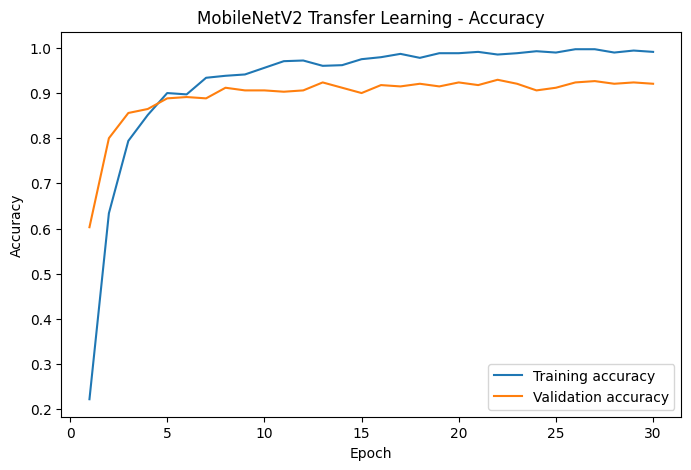

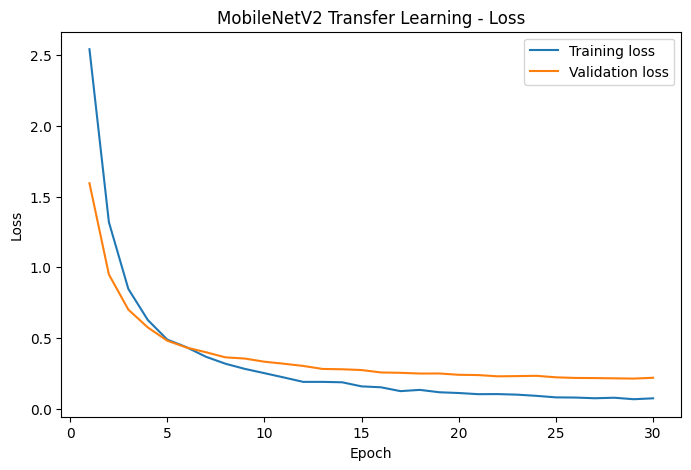

In [23]:
# 19. PLOT MOBILENETV2 HISTORY
# ---------------------------

plot_history(
    mobilenet_history,
    "MobileNetV2 Transfer Learning"
)

In [24]:
# FINAL TEST EVALUATION
# ============================================================

# IMPORTANT:
# Do not use test_ds for repeated model tuning.
# This section is intended to be run after model development
# decisions have been completed.

# ---------------------------
# 20. TEST ACCURACY
# ---------------------------

scratch_test_loss, scratch_test_accuracy = scratch_model.evaluate(
    test_ds,
    verbose=0
)

mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=0
)

print("CNN FROM SCRATCH")
print("Test loss:", scratch_test_loss)
print("Test accuracy:", scratch_test_accuracy)

print("\nMOBILENETV2")
print("Test loss:", mobilenet_test_loss)
print("Test accuracy:", mobilenet_test_accuracy)


CNN FROM SCRATCH
Test loss: 1.4552969932556152
Test accuracy: 0.5264706015586853

MOBILENETV2
Test loss: 0.18484258651733398
Test accuracy: 0.9617646932601929


In [25]:
# 21. GENERATE TEST PREDICTIONS
# ---------------------------
# Convert probabilities into predicted class numbers.

y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])


scratch_probabilities = scratch_model.predict(
    test_ds,
    verbose=0
)

scratch_predictions = np.argmax(
    scratch_probabilities,
    axis=1
)


mobilenet_probabilities = mobilenet_model.predict(
    test_ds,
    verbose=0
)

mobilenet_predictions = np.argmax(
    mobilenet_probabilities,
    axis=1
)

In [26]:
# 22. CLASSIFICATION REPORTS
# ---------------------------
# Precision, recall and F1-score provide more detail than
# overall accuracy alone.

print("\nCNN FROM SCRATCH - CLASSIFICATION REPORT")
print(
    classification_report(
        y_true,
        scratch_predictions,
        target_names=class_names,
        digits=4
    )
)


print("\nMOBILENETV2 - CLASSIFICATION REPORT")
print(
    classification_report(
        y_true,
        mobilenet_predictions,
        target_names=class_names,
        digits=4
    )
)


CNN FROM SCRATCH - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Daffodil     0.2500    0.3000    0.2727        20
    Snowdrop     0.3023    0.6500    0.4127        20
 Lily Valley     0.6500    0.6500    0.6500        20
    Bluebell     0.6000    0.6000    0.6000        20
      Crocus     0.4000    0.6000    0.4800        20
        Iris     0.0000    0.0000    0.0000        20
   Tigerlily     0.8000    0.8000    0.8000        20
       Tulip     0.5000    0.2500    0.3333        20
  Fritillary     0.7895    0.7500    0.7692        20
   Sunflower     0.8571    0.6000    0.7059        20
       Daisy     0.8000    0.8000    0.8000        20
  Colts Foot     0.4048    0.8500    0.5484        20
   Dandelion     0.4286    0.4500    0.4390        20
     Cowslip     0.6429    0.4500    0.5294        20
   Buttercup     0.5833    0.3500    0.4375        20
  Windflower     0.5882    0.5000    0.5405        20
       Pansy     0.6364    0.3500    0.

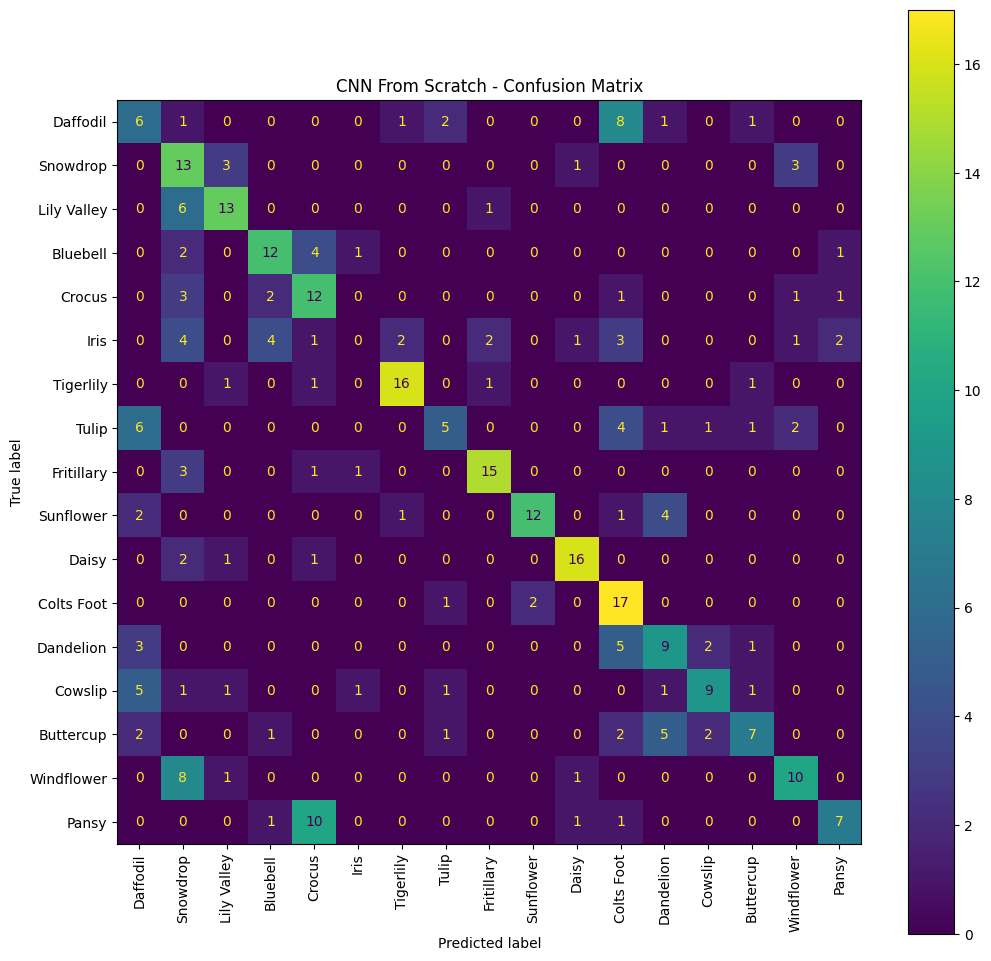

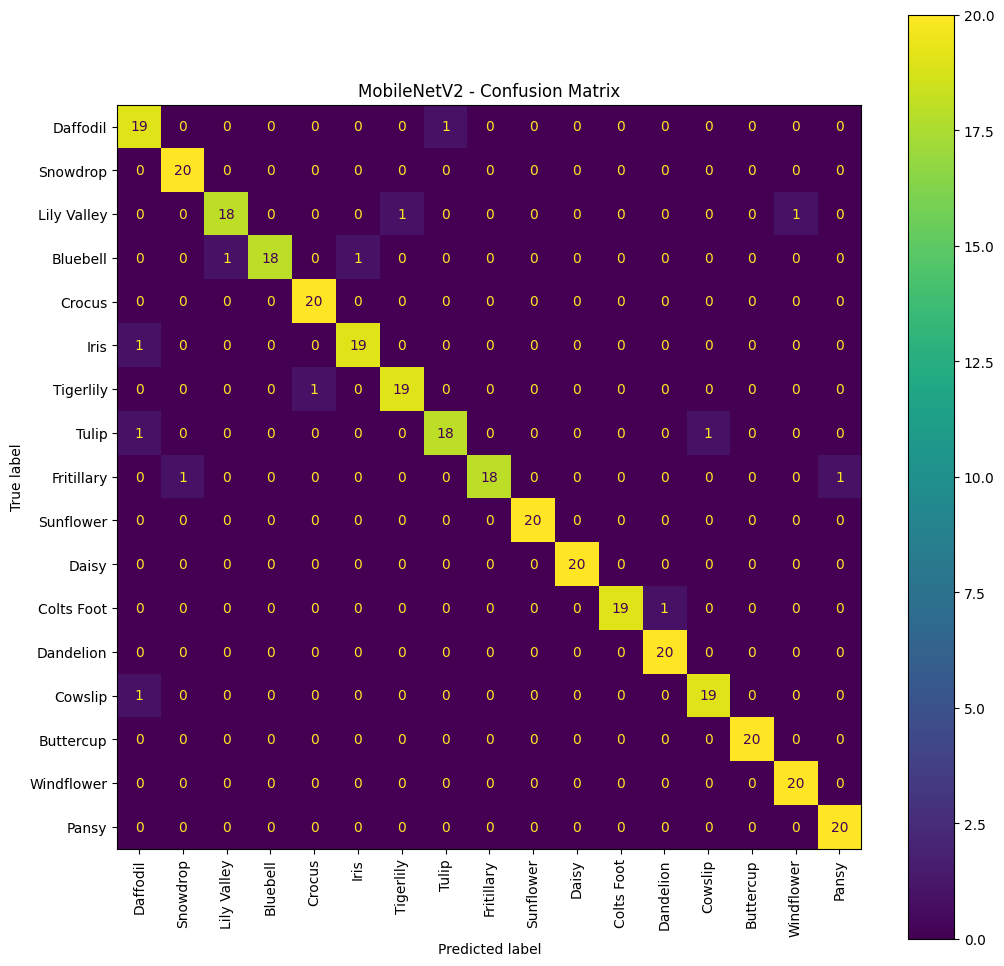

In [27]:
# 23. CONFUSION MATRICES
# ---------------------------
# These reveal which flower classes are most often confused.

scratch_cm = confusion_matrix(
    y_true,
    scratch_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=scratch_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)
plt.title("CNN From Scratch - Confusion Matrix")
plt.show()


mobilenet_cm = confusion_matrix(
    y_true,
    mobilenet_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=mobilenet_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)
plt.title("MobileNetV2 - Confusion Matrix")
plt.show()

In [28]:
# 24. COMPARE MODEL SIZE AND TRAINING TIME
# ---------------------------

def count_trainable_parameters(model):
    return int(
        np.sum([
            np.prod(variable.shape)
            for variable in model.trainable_weights
        ])
    )


scratch_trainable = count_trainable_parameters(
    scratch_model
)

mobilenet_trainable = count_trainable_parameters(
    mobilenet_model
)


print("\nFINAL COMPARISON")
print("-" * 60)

print(
    f"Scratch CNN test accuracy: "
    f"{scratch_test_accuracy:.4f}"
)

print(
    f"MobileNetV2 test accuracy: "
    f"{mobilenet_test_accuracy:.4f}"
)

print(
    f"Scratch CNN training time: "
    f"{scratch_training_time:.2f} seconds"
)

print(
    f"MobileNetV2 training time: "
    f"{mobilenet_training_time:.2f} seconds"
)

print(
    f"Scratch CNN trainable parameters: "
    f"{scratch_trainable:,}"
)

print(
    f"MobileNetV2 trainable parameters: "
    f"{mobilenet_trainable:,}"
)



FINAL COMPARISON
------------------------------------------------------------
Scratch CNN test accuracy: 0.5265
MobileNetV2 test accuracy: 0.9618
Scratch CNN training time: 70.55 seconds
MobileNetV2 training time: 89.74 seconds
Scratch CNN trainable parameters: 392,785
MobileNetV2 trainable parameters: 21,777



MobileNetV2 example errors:


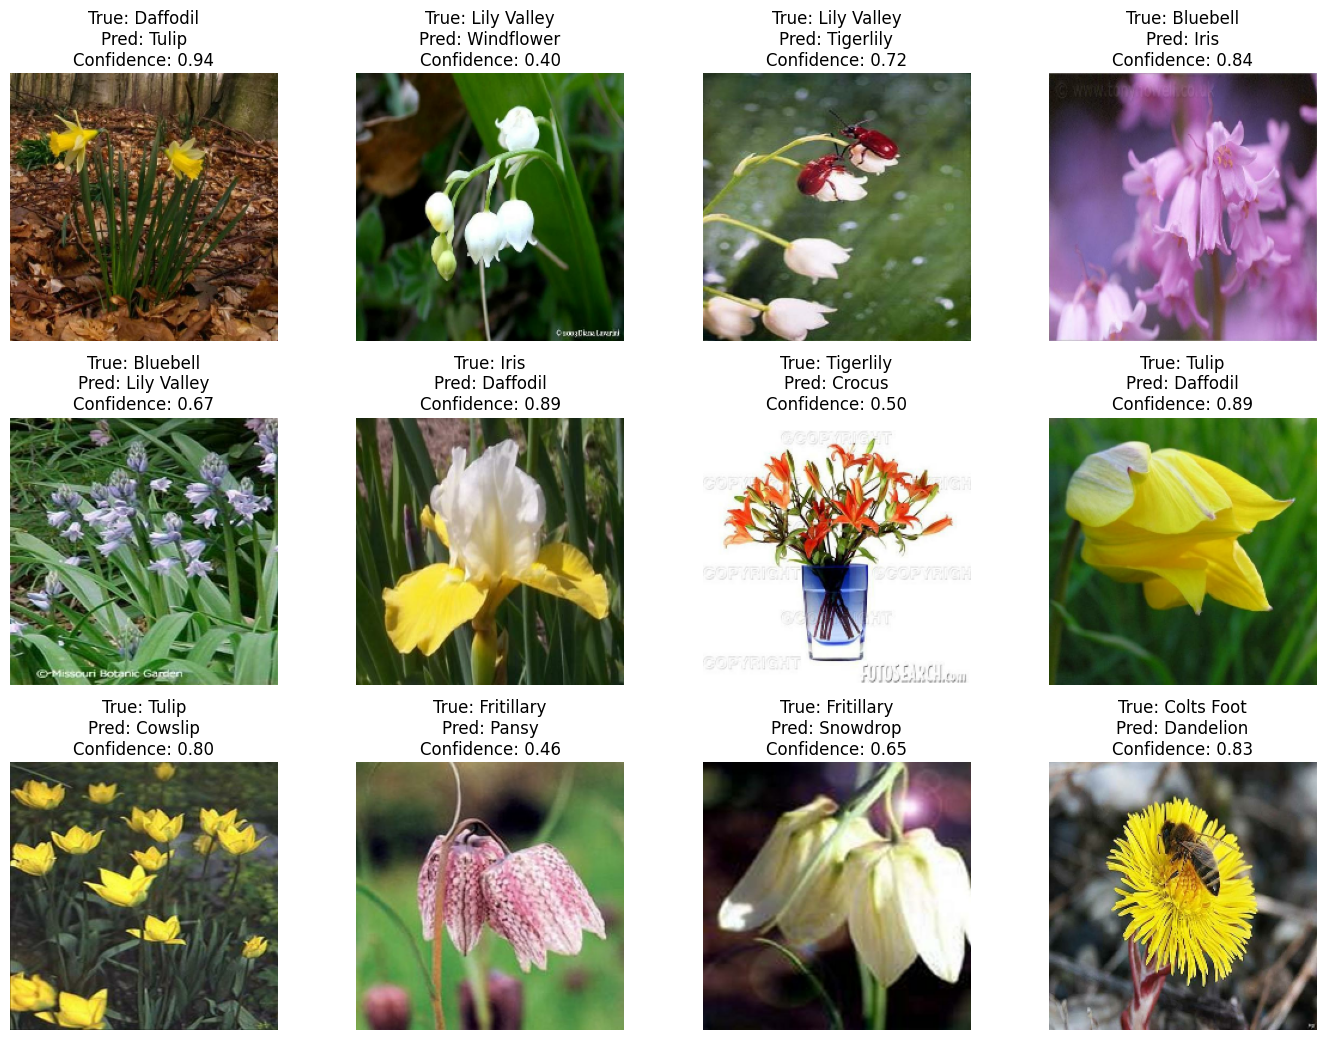

In [29]:
# 25. VISUALISE EXAMPLE ERRORS
# ---------------------------
# Looking at incorrect predictions helps explain model
# weaknesses that accuracy alone cannot show.

def show_misclassified_examples(
    model,
    dataset,
    class_names,
    max_images=12
):
    examples = []

    for batch_images, batch_labels in dataset:
        probabilities = model.predict(
            batch_images,
            verbose=0
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        for image, true_label, predicted_label, prob in zip(
            batch_images,
            batch_labels.numpy(),
            predictions,
            probabilities
        ):
            if true_label != predicted_label:
                confidence = prob[predicted_label]

                examples.append(
                    (
                        image.numpy(),
                        int(true_label),
                        int(predicted_label),
                        float(confidence)
                    )
                )

            if len(examples) >= max_images:
                break

        if len(examples) >= max_images:
            break

    if not examples:
        print("No misclassified examples found.")
        return

    rows = int(np.ceil(len(examples) / 4))

    plt.figure(figsize=(14, 3.5 * rows))

    for i, (
        image,
        true_label,
        predicted_label,
        confidence
    ) in enumerate(examples):

        plt.subplot(rows, 4, i + 1)
        plt.imshow(image.astype("uint8"))

        plt.title(
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[predicted_label]}\n"
            f"Confidence: {confidence:.2f}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


print("\nMobileNetV2 example errors:")
show_misclassified_examples(
    mobilenet_model,
    test_ds,
    class_names
)


In [30]:
# 26. SAVE THE MODELS
# ---------------------------
# The trained models can later be loaded without retraining.

scratch_model.save(
    "/content/scratch_flower_cnn.keras"
)

mobilenet_model.save(
    "/content/mobilenetv2_flower_classifier.keras"
)

print("Models saved successfully.")



Models saved successfully.


In [33]:
# 27. PREDICT A SINGLE NEW IMAGE
# ---------------------------
# Use this function later to classify an individual flower
# image with one of the trained models.

def predict_flower(model, image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )
    image = tf.cast(
        image,
        tf.float32
    )

    image = tf.expand_dims(
        image,
        axis=0
    )

    probabilities = model.predict(
        image,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[predicted_index]
    )

    print(
        "Predicted flower:",
        class_names[predicted_index]
    )

    print(
        "Confidence:",
        round(confidence, 4)
    )

    return class_names[predicted_index], confidence


# Example usage:
#
# predict_flower(
#     mobilenet_model,
#     "/content/my_flower.jpg"
# )
